In [1]:
import aqua

from aqua.batchAQUA_general import batchAQUA
from aqua.utils import *
from aqua.stimulus import *

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, windows

from changepoynt.algorithms.esst import ESST
from changepoynt.visualization.score_plotting import plot_data_and_score


In [2]:
RS = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0., 'f': 0., 'tau': 0.}

RS_aut = {'name': 'RS_ref', 'C': 100, 'k': 0.7, 'v_r': -60, 'v_t': -40, 'v_peak': 35,
     'a': 0.03, 'b': -2, 'c': -50, 'd': 100, 'e': 0.2, 'f': 250., 'tau': 2.}

CHANGE POINT: 15000


100%|██████████| 29999/29999 [00:03<00:00, 7728.51it/s]


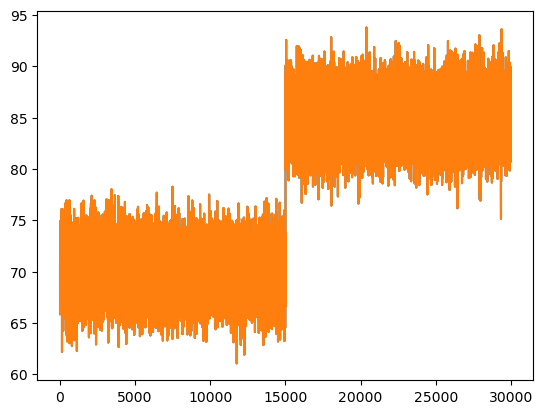

In [3]:
# Base autapse parameters

T = 3000 # ms
dt = 0.1
N_iter = int(T/dt)

'''
# injected current, staircase current
I_hs = np.arange(50, 151, 20)
I_inj = np.ones((2, N_iter))
I_segment = N_iter//len(I_hs)
for n, i in enumerate(I_hs):
    I_inj[:, n*I_segment:(n+1)*I_segment] = i*np.ones((2, I_segment))
'''
# test an injected current with only one change point
changepoint = int(N_iter/2)
print(f"CHANGE POINT: {changepoint}")
variance = 5
I_h = 60
noise = np.random.normal(loc = 0.0, scale = np.sqrt(variance), size = (N_iter))
Y = np.ones(N_iter)
Y[:changepoint] = 10
Y[changepoint:] = 25
Y += noise + I_h
I_inj = np.array([Y, Y])

plt.plot(I_inj[0, :])
plt.plot(I_inj[1, :])

# initial cond.
x_ini = np.array([-60, 0, 0])
x_start = np.full((2, 3), fill_value = x_ini)
t_ini = np.array([0., 0.])

# create neuron
batch = batchAQUA([RS, RS_aut])
batch.Initialise(x_start, t_ini)

# simulate
X, time, spikes = batch.update_batch(dt, N_iter, I_inj)

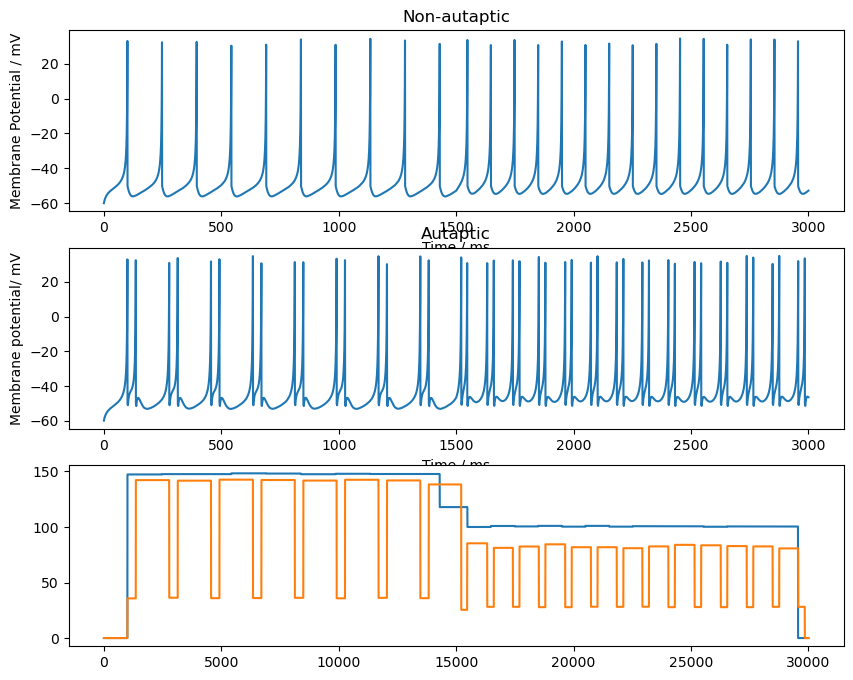

In [4]:
# plot output
fig, ax = plt.subplots(3, 1, figsize = (10, 8))

ax[0].plot(time, X[0, 0, :], label = "non-autaptic")
#ax[0].plot(time, X[1, 0, :], label = "test")
ax[0].set_xlabel("Time / ms")
ax[0].set_ylabel("Membrane Potential / mV")
ax[0].set_title("Non-autaptic")

ax[1].plot(time, X[1, 0, :], label = "autaptic")
ax[1].set_xlabel("Time / ms")
ax[1].set_ylabel("Membrane potential/ mV")
ax[1].set_title("Autaptic")

"""
ax[2].plot(time, I_inj[0, :], label = "I_inj")
ax[2].set_xlabel("Time / ms")
ax[2].set_ylabel("Injected Current / pA")
plt.legend()
"""

# create an ISI plot....
ISI_trace = np.zeros((2, N_iter))
ISIs = np.diff(spikes, axis = 1)

for n, row in enumerate(spikes):
    for i in range(len(row[~np.isnan(row)])-1):

        idx_1 = int(row[i]/dt)
        idx_2 = int(row[i+1]/dt)
        ISI_trace[n, idx_1:idx_2] = ISIs[n, i]
        
ax[2].plot(ISI_trace[0, :])
ax[2].plot(ISI_trace[1, :])

In [5]:
''' TEST THE CHANGEPOINT ANALYSIS HERE '''
"""
# make change point detection
esst_detector = ESST(2000)
esst_detection_RAW_AUT = esst_detector.transform(X[1, 0, :])
esst_detection_RAW_NAUT = esst_detector.transform(X[0, 0, :])

esst_detection_FILT_AUT = esst_detector.transform(smooth_rate[1, 1000:-1000])
esst_detection_FILT_NAUT = esst_detector.transform(smooth_rate[0, 1000:-1000])


# make the plot
plot_data_and_score(X[1, 0, :], esst_detection_RAW_AUT)
plt.gcf().tight_layout()

plot_data_and_score(X[0, 0, :], esst_detection_RAW_NAUT)
plt.gcf().tight_layout()

plot_data_and_score(smooth_rate[1, 1000:-1000], esst_detection_FILT_AUT)
plt.gcf().tight_layout()

plot_data_and_score(smooth_rate[0, 1000:-1000], esst_detection_FILT_NAUT)
plt.gcf().tight_layout()
"""


'\n# make change point detection\nesst_detector = ESST(2000)\nesst_detection_RAW_AUT = esst_detector.transform(X[1, 0, :])\nesst_detection_RAW_NAUT = esst_detector.transform(X[0, 0, :])\n\nesst_detection_FILT_AUT = esst_detector.transform(smooth_rate[1, 1000:-1000])\nesst_detection_FILT_NAUT = esst_detector.transform(smooth_rate[0, 1000:-1000])\n\n\n# make the plot\nplot_data_and_score(X[1, 0, :], esst_detection_RAW_AUT)\nplt.gcf().tight_layout()\n\nplot_data_and_score(X[0, 0, :], esst_detection_RAW_NAUT)\nplt.gcf().tight_layout()\n\nplot_data_and_score(smooth_rate[1, 1000:-1000], esst_detection_FILT_AUT)\nplt.gcf().tight_layout()\n\nplot_data_and_score(smooth_rate[0, 1000:-1000], esst_detection_FILT_NAUT)\nplt.gcf().tight_layout()\n'

AUTAPSE
FLUSS score: 0.9977155259760335
ANOMALY TIME: 14809
- - - - - - -
NO AUTAPSE
FLUSS score: 0.860808083386798
ANOMALY TIME: 15031


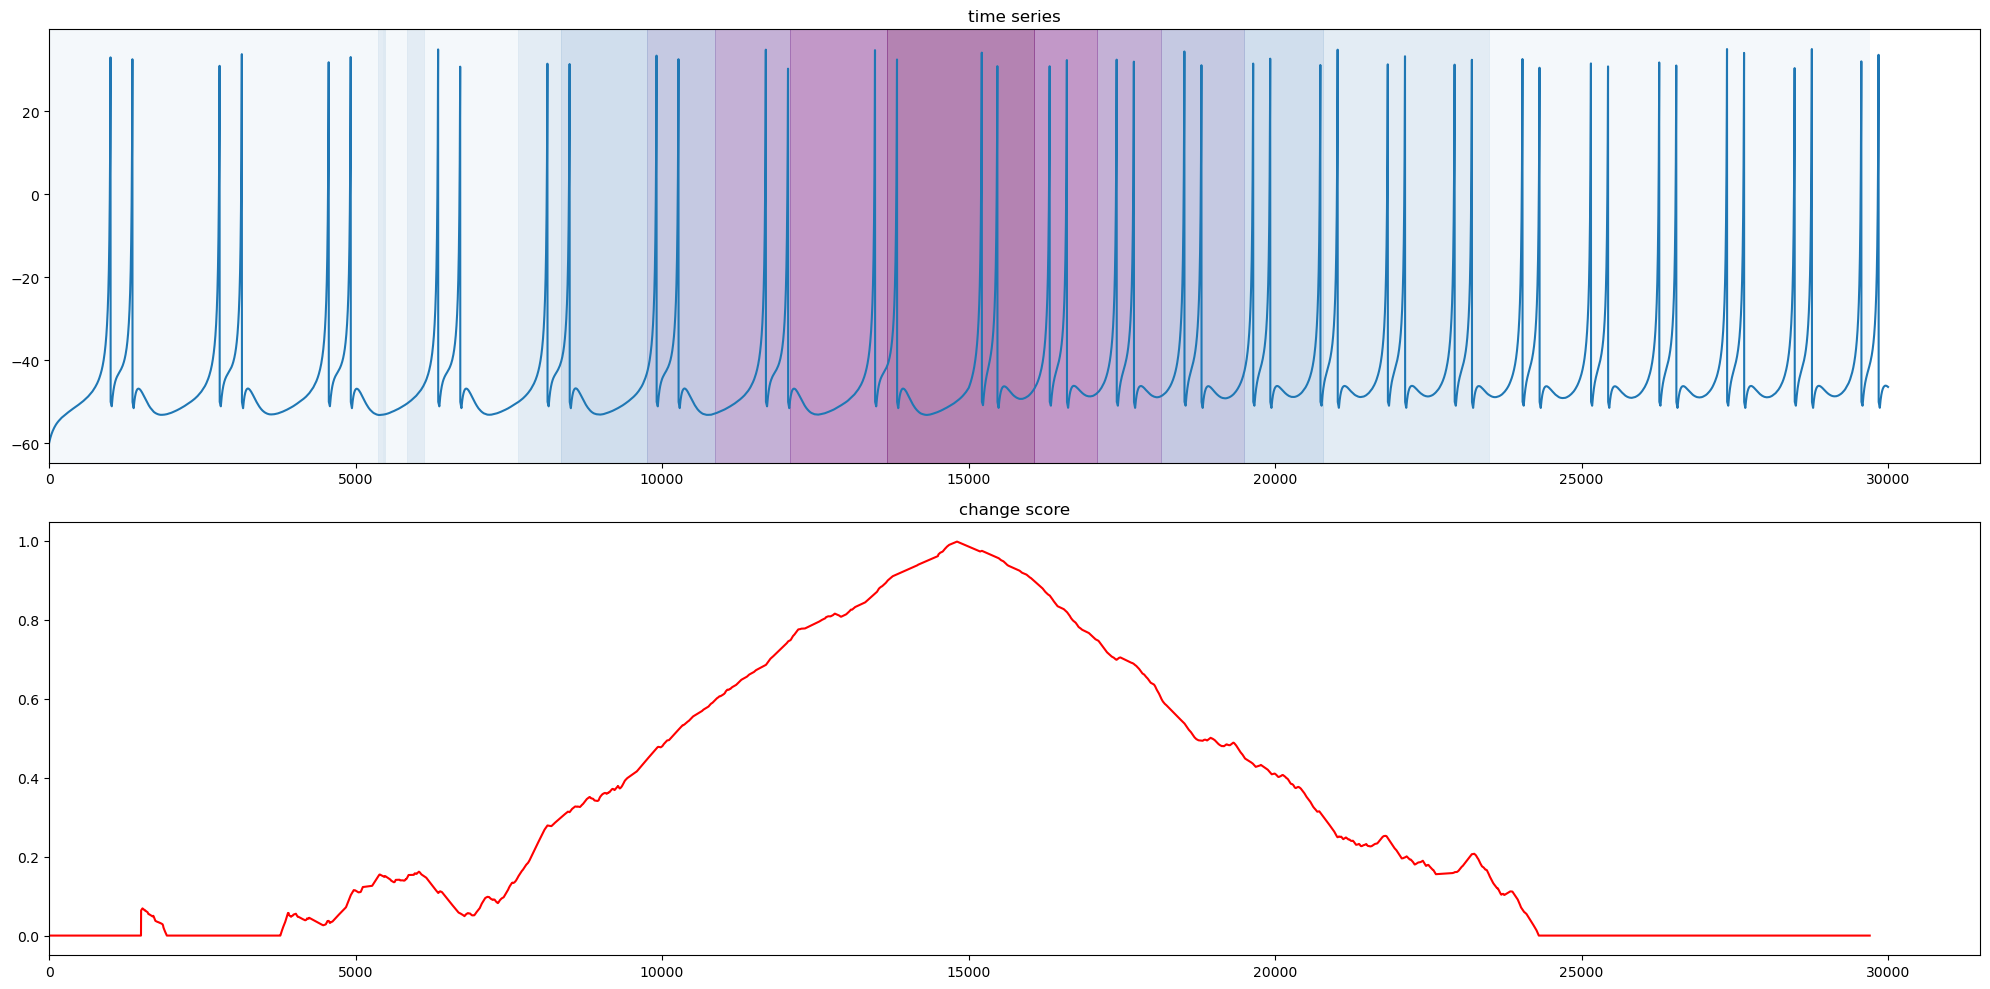

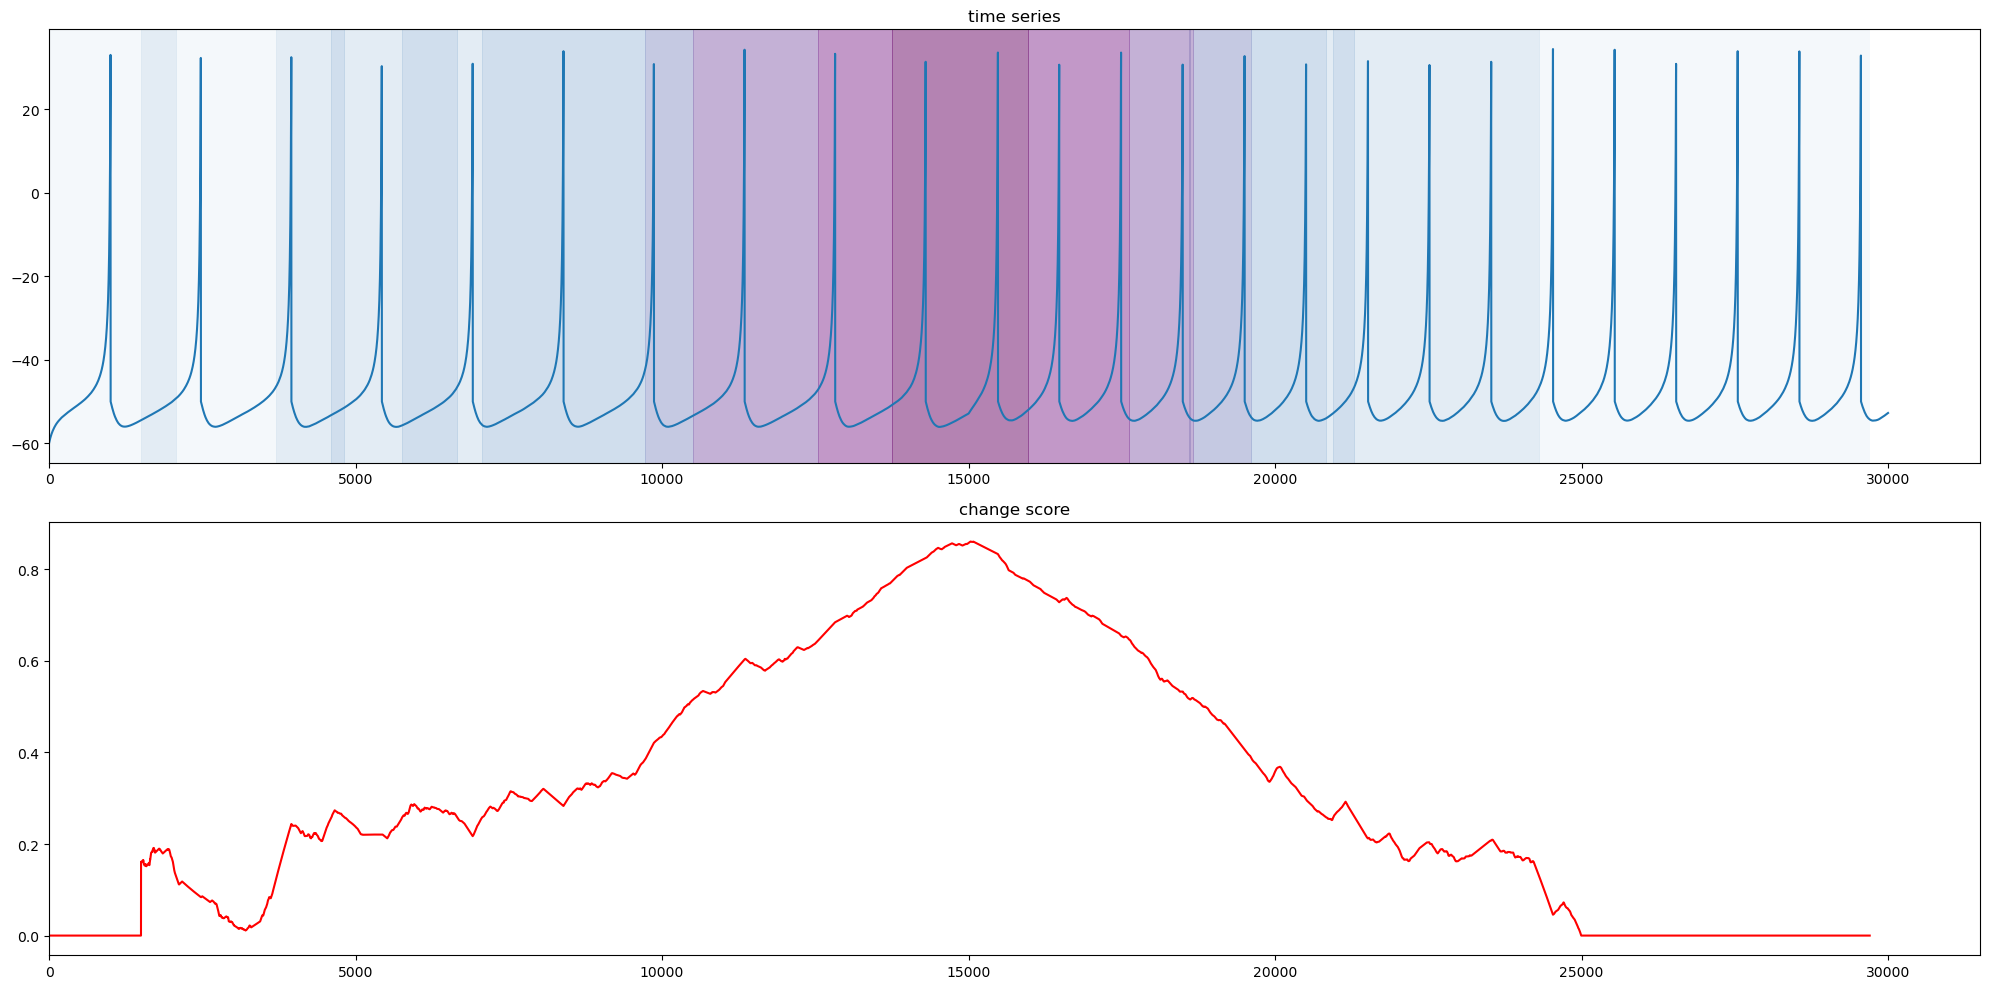

In [10]:
''' TRY THE FLUSS algorithm using matrix profile'''
from changepoynt.algorithms.fluss import FLUSS

fluss_detector = FLUSS(window_length = 300)

score_raw_aut = fluss_detector.transform(X[1, 0, :])
score_raw_naut = fluss_detector.transform(X[0, 0, :])

print('AUTAPSE')
print(f'FLUSS score: {np.max(score_raw_aut)}')
print(f'ANOMALY TIME: {np.argmax(score_raw_aut)}')
print("- - - - - - -")
print('NO AUTAPSE')
print(f'FLUSS score: {np.max(score_raw_naut)}')
print(f'ANOMALY TIME: {np.argmax(score_raw_naut)}')


#score_filt_aut = fluss_detector.transform(smooth_rate[1, :])
#score_filt_naut = fluss_detector.transform(smooth_rate[0, :])

# make the plot

plot_data_and_score(X[1, 0, :], score_raw_aut)
plt.gcf().tight_layout()

plot_data_and_score(X[0, 0, :], score_raw_naut)
plt.gcf().tight_layout()

# Plots on the filtered spiking data
#plot_data_and_score(smooth_rate[1, :], score_filt_aut)
#plt.gcf().tight_layout()

#plot_data_and_score(smooth_rate[0, :], score_filt_naut)
#plt.gcf().tight_layout()

In [8]:
''' TRY the RuLSIF algorithm using matrix profile'''
"""
from changepoynt.algorithms.rulsif import RuLSIF

rulsif_detector = RuLSIF(window_length = 1000)

score_raw_aut = rulsif_detector.transform(X[1, 0, :])
score_raw_naut = rulsif_detector.transform(X[0, 0, :])

print('AUTAPSE')
print(f'FLUSS score: {np.max(score_raw_aut)}')
print(f'ANOMALY TIME: {np.argmax(score_raw_aut)}')
print("- - - - - - -")
print('NO AUTAPSE')
print(f'FLUSS score: {np.max(score_raw_naut)}')
print(f'ANOMALY TIME: {np.argmax(score_raw_naut)}')


#score_filt_aut = fluss_detector.transform(smooth_rate[1, :])
#score_filt_naut = fluss_detector.transform(smooth_rate[0, :])

# make the plot

plot_data_and_score(X[1, 0, :], score_raw_aut)
plt.gcf().tight_layout()

plot_data_and_score(X[0, 0, :], score_raw_naut)
plt.gcf().tight_layout()
"""

'\nfrom changepoynt.algorithms.rulsif import RuLSIF\n\nrulsif_detector = RuLSIF(window_length = 1000)\n\nscore_raw_aut = rulsif_detector.transform(X[1, 0, :])\nscore_raw_naut = rulsif_detector.transform(X[0, 0, :])\n\nprint(\'AUTAPSE\')\nprint(f\'FLUSS score: {np.max(score_raw_aut)}\')\nprint(f\'ANOMALY TIME: {np.argmax(score_raw_aut)}\')\nprint("- - - - - - -")\nprint(\'NO AUTAPSE\')\nprint(f\'FLUSS score: {np.max(score_raw_naut)}\')\nprint(f\'ANOMALY TIME: {np.argmax(score_raw_naut)}\')\n\n\n#score_filt_aut = fluss_detector.transform(smooth_rate[1, :])\n#score_filt_naut = fluss_detector.transform(smooth_rate[0, :])\n\n# make the plot\n\nplot_data_and_score(X[1, 0, :], score_raw_aut)\nplt.gcf().tight_layout()\n\nplot_data_and_score(X[0, 0, :], score_raw_naut)\nplt.gcf().tight_layout()\n'